# Pregunta 2: Ecualización Local y Control de Contraste (20 puntos)

Implemente un algoritmo de ecualización local de histograma para imágenes en escala de grises utilizando obligatoriamente una malla de regiones. La transformación aplicada a un píxel debe depender de una o más regiones locales de la imagen, y la implementación debe considerar de manera explícita cómo se combinan o interpolan las transformaciones cuando las regiones se solapan.

La geometría de la malla deberá ser parametrizable. Como mínimo, deberá poder controlar el tamaño de las regiones y la distancia entre regiones vecinas o entre sus centros. El grado de *interlaced/overlap* puede definirse directamente o de manera indirecta mediante la relación entre el tamaño de la región y la separación entre regiones.

El algoritmo base debe implementar una ecualización local sin limitación de contraste y ser suficientemente flexible como para reproducir la ecualización clásica global utilizando una única región que abarque la imagen completa.

---

In [8]:
%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt
import cv2


from codigo.p2_ecualizacion import ecualizacion_local_malla, clahe_referencia_cv2, graficar_histograma_comparativo, calcular_cdf_ecualizacion
from codigo.utilidades import cargar_imagen_rgb

os.makedirs('../figuras/p2', exist_ok=True)
print("Entorno listo para Pregunta 2.")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Entorno listo para Pregunta 2.


## P2 — Experimentación y Análisis (8 puntos)
1. **Equivalencia global:** 
---

### Construcción y Efecto del Histograma Local

El núcleo de la ecualización adaptativa descansa en cómo se comporta la distribución estadística de cada bloque. En el código, la función `np.histogram` captura eficientemente la frecuencia de los niveles de intensidad en cada submatriz. Al aplicar una suma acumulativa con `.cumsum()` y normalizar por el número total de píxeles, obtenemos la función de distribución acumulativa (CDF) empírica, la cual actúa directamente como la tabla de mapeo $T_{\text{local}}(r)$.

Cuando se reduce drásticamente el número de bins (por ejemplo, a 16 o 64 bins en la figura `05_sensibilidad_bins.png`), el histograma pierde resolución tonal fina. Esto provoca que múltiples intensidades originales compartan el mismo valor acumulado en la CDF, transformándola en una función escalonada con saltos bruscos. Visualmente, esto se traduce en artefactos de cuantización o falso contorno (*banding*), destruyendo las transiciones suaves de la imagen.

In [9]:
# Cargar imágenes y convertir a escala de grises [0, 1]
rgb1 = cargar_imagen_rgb("P2_IMG_2423.tif")
img_gray1 = cv2.cvtColor((rgb1 * 255.0).astype(np.uint8), cv2.COLOR_RGB2GRAY).astype(np.float64) / 255.0

rgb2 = cargar_imagen_rgb("P1_IMG_2402.tif")
img_gray2 = cv2.cvtColor((rgb2 * 255.0).astype(np.uint8), cv2.COLOR_RGB2GRAY).astype(np.float64) / 255.0

print(f"Imagen 1 (P2): dimensiones {img_gray1.shape}")
print(f"Imagen 2 (P1): dimensiones {img_gray2.shape}")

Imagen 1 (P2): dimensiones (1154, 1734)
Imagen 2 (P1): dimensiones (5202, 3464)


Diferencia máxima entre nuestra ecualización global y cv2.equalizeHist: 0.035551


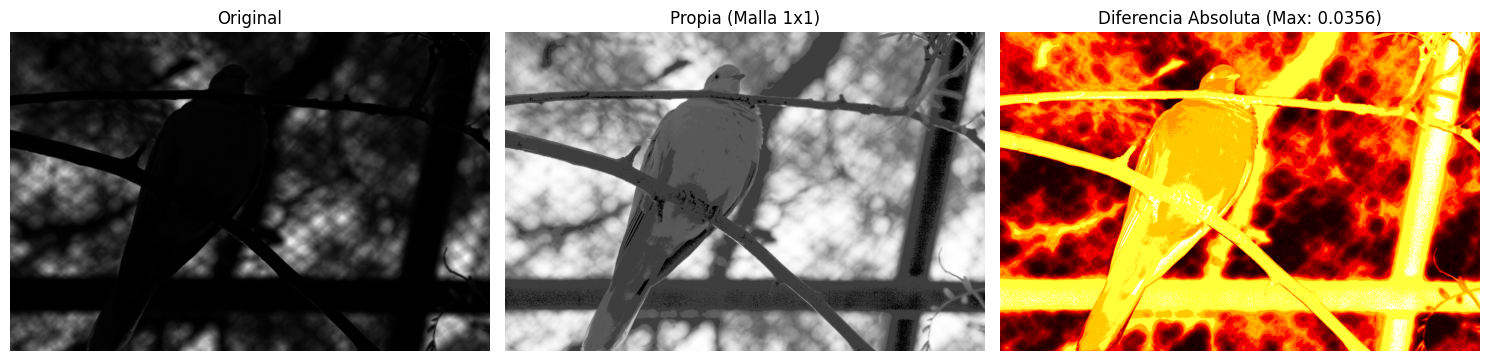

In [10]:
# 1. Ecualización global con nuestro algoritmo base (malla 1x1, alpha=1.0)
eq_global_propia = ecualizacion_local_malla(img_gray1, n_regiones_y=1, n_regiones_x=1, alpha_contraste=1.0)

# 2. Ecualización global clásica con OpenCV estándar
eq_global_cv2 = cv2.equalizeHist((img_gray1 * 255.0).astype(np.uint8)).astype(np.float64) / 255.0

# 3. Diferencia absoluta
dif_max = np.max(np.abs(eq_global_propia - eq_global_cv2))
print(f"Diferencia máxima entre nuestra ecualización global y cv2.equalizeHist: {dif_max:.6f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(img_gray1, cmap='gray')
axes[0].set_title("Original")
axes[0].axis('off')

axes[1].imshow(eq_global_propia, cmap='gray')
axes[1].set_title("Propia (Malla 1x1)")
axes[1].axis('off')

axes[2].imshow(np.abs(eq_global_propia - eq_global_cv2), cmap='hot')
axes[2].set_title(f"Diferencia Absoluta (Max: {dif_max:.4f})")
axes[2].axis('off')

plt.tight_layout()
plt.savefig('../figuras/p2/01_verificacion_global.png', dpi=300, bbox_inches='tight')
plt.show()

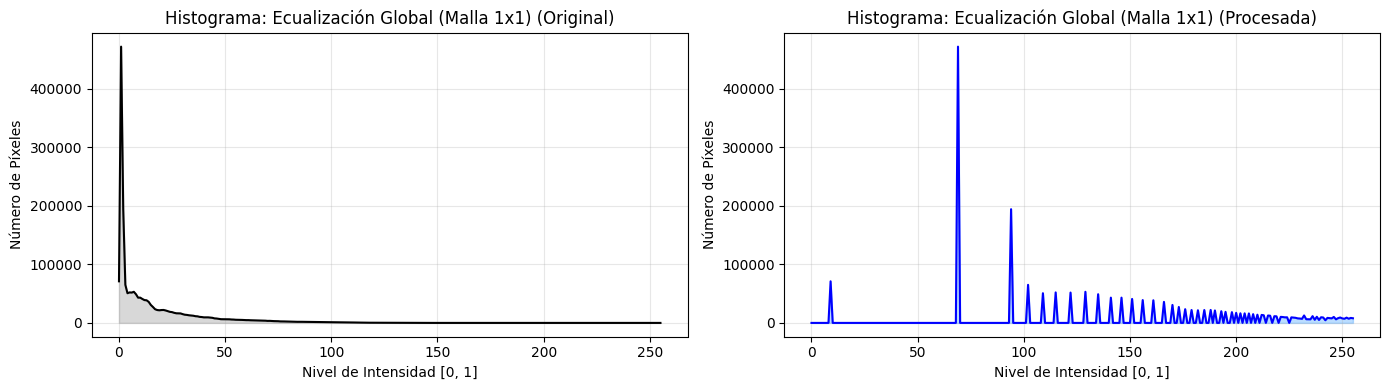

In [11]:
eq_global_propia = ecualizacion_local_malla(
    img_gray1, n_regiones_y=1, n_regiones_x=1, alpha_contraste=1.0
)
graficar_histograma_comparativo(img_gray1, eq_global_propia, titulo="Ecualización Global (Malla 1x1)")

2. **Geometría de la malla:** 
---

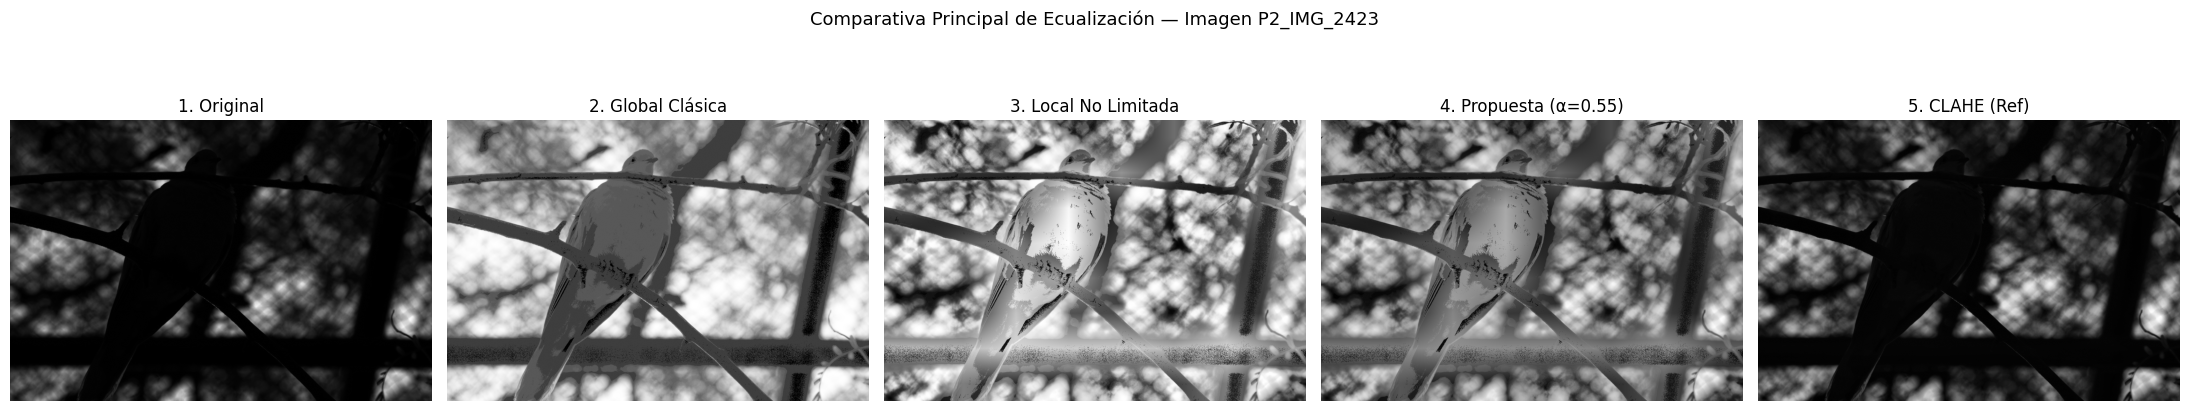

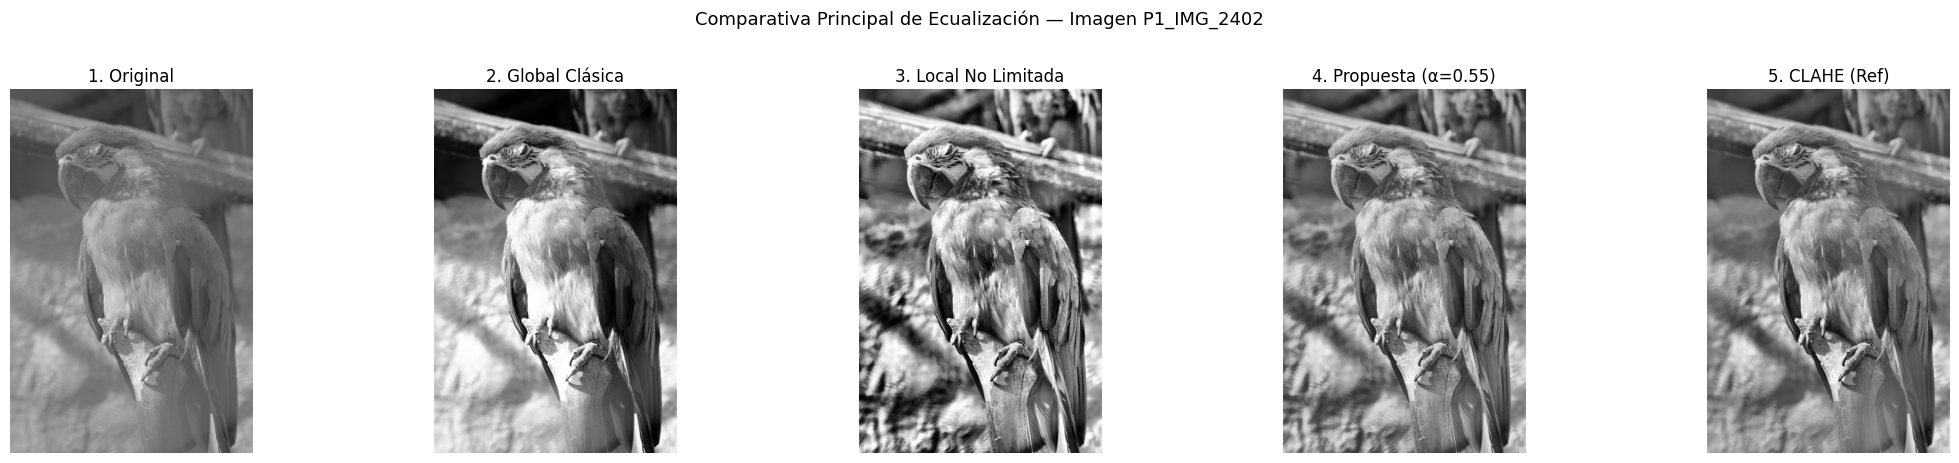

In [12]:
def comparar_metodos_ecualizacion(img_in: np.ndarray, titulo_sufijo: str, ruta_out: str):
    # Procesamientos
    res_global = ecualizacion_local_malla(img_in, n_regiones_y=1, n_regiones_x=1, alpha_contraste=1.0)
    res_local_no_lim = ecualizacion_local_malla(img_in, n_regiones_y=8, n_regiones_x=8, alpha_contraste=1.0)
    res_propuesto = ecualizacion_local_malla(img_in, n_regiones_y=8, n_regiones_x=8, alpha_contraste=0.55, modo_control="mezcla")
    res_clahe = clahe_referencia_cv2(img_in, clip_limit=2.0, tile_grid_size=(8, 8))

    fig, axes = plt.subplots(1, 5, figsize=(22, 4.5))
    axes[0].imshow(img_in, cmap='gray'); axes[0].set_title("1. Original"); axes[0].axis('off')
    axes[1].imshow(res_global, cmap='gray'); axes[1].set_title("2. Global Clásica"); axes[1].axis('off')
    axes[2].imshow(res_local_no_lim, cmap='gray'); axes[2].set_title("3. Local No Limitada"); axes[2].axis('off')
    axes[3].imshow(res_propuesto, cmap='gray'); axes[3].set_title("4. Propuesta (α=0.55)"); axes[3].axis('off')
    axes[4].imshow(res_clahe, cmap='gray'); axes[4].set_title("5. CLAHE (Ref)"); axes[4].axis('off')

    plt.suptitle(f"Comparativa Principal de Ecualización — {titulo_sufijo}", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig(ruta_out, dpi=300, bbox_inches='tight')
    plt.show()

comparar_metodos_ecualizacion(img_gray1, "Imagen P2_IMG_2423", "../figuras/p2/02_quinteto_comparativo_p2.png")
comparar_metodos_ecualizacion(img_gray2, "Imagen P1_IMG_2402", "../figuras/p2/03_quinteto_comparativo_p1.png")

3. **Número de bins:** 
---

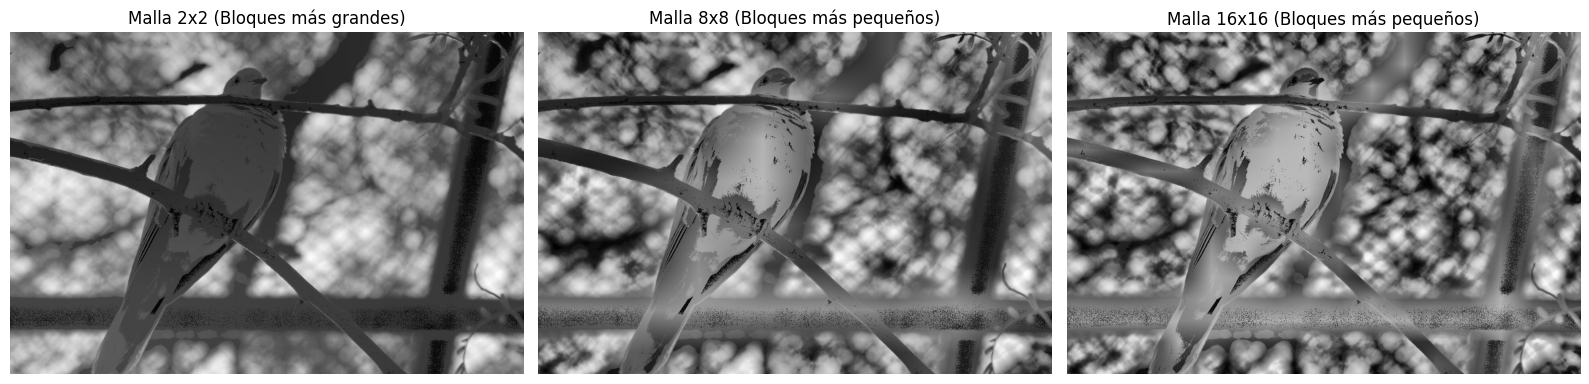

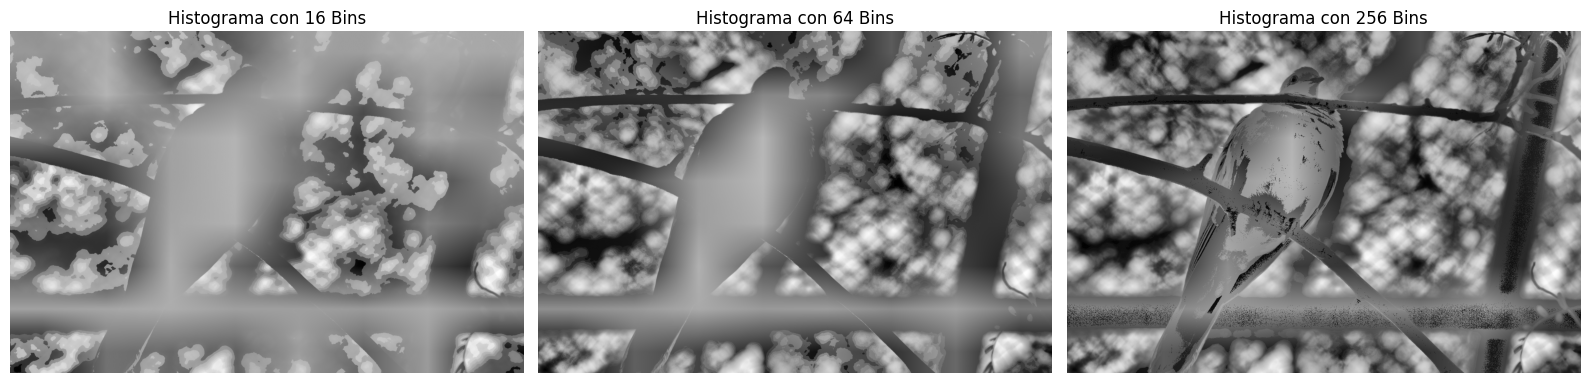

In [13]:
# Efecto de la geometría de la malla: Mallas 2x2, 8x8 y 16x16
mallas = [(2, 2), (8, 8), (16, 16)]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, (ny, nx) in enumerate(mallas):
    res_malla = ecualizacion_local_malla(img_gray1, n_regiones_y=ny, n_regiones_x=nx, alpha_contraste=0.6)
    axes[idx].imshow(res_malla, cmap='gray')
    axes[idx].set_title(f"Malla {ny}x{nx} (Bloques más {'grandes' if ny==2 else 'pequeños'})")
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('../figuras/p2/04_geometria_malla.png', dpi=300, bbox_inches='tight')
plt.show()

# Efecto del número de bins (Bins = 16, 64, 256)
bins_test = [16, 64, 256]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, nb in enumerate(bins_test):
    res_bins = ecualizacion_local_malla(img_gray1, n_regiones_y=8, n_regiones_x=8, num_bins=nb, alpha_contraste=0.6)
    axes[idx].imshow(res_bins, cmap='gray')
    axes[idx].set_title(f"Histograma con {nb} Bins")
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('../figuras/p2/05_sensibilidad_bins.png', dpi=300, bbox_inches='tight')
plt.show()

Al variar la densidad de la malla (bloques $2\times2$, $8\times8$ y $16\times16$ en `04_geometria_malla.png`), se evidencia un delicado equilibrio espacial. Con una malla gruesa ($2\times2$), las regiones son tan extensas que el algoritmo se comporta prácticamente de forma global, perdiendo la capacidad de rescatar detalles en zonas de iluminación compleja. En el extremo opuesto, una malla hiperdensa ($16\times16$) fragmenta el espacio en bloques diminutos; la estadística local se vuelve hiper-sensible a variaciones minúsculas y el resultado adquiere un aspecto sobreprocesado. El espacio de trabajo óptimo se sitúa en mallas intermedias (como $8\times8$), donde la relación entre el tamaño de la región y la separación de sus centros genera un solapamiento (*overlap*) adecuado para alimentar la interpolación espacial.

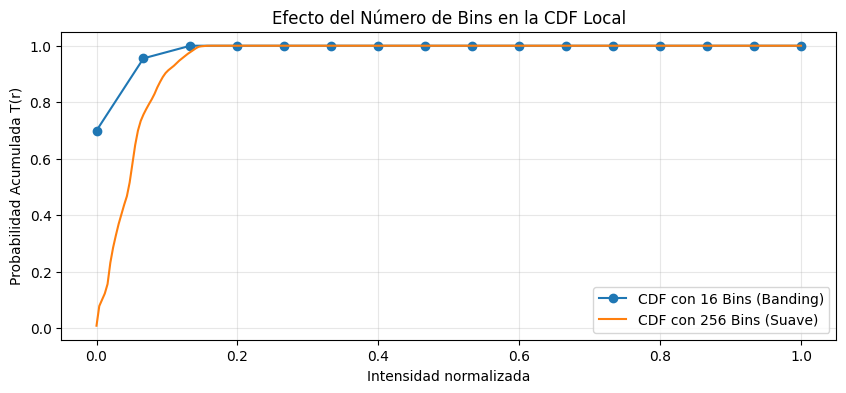

In [14]:
sub_ejemplo = img_gray1[:200, :200]
cdf_16 = calcular_cdf_ecualizacion(sub_ejemplo, num_bins=16)
cdf_256 = calcular_cdf_ecualizacion(sub_ejemplo, num_bins=256)

plt.figure(figsize=(10, 4))
plt.plot(np.linspace(0, 1, 16), cdf_16, marker='o', label="CDF con 16 Bins (Banding)")
plt.plot(np.linspace(0, 1, 256), cdf_256, label="CDF con 256 Bins (Suave)")
plt.title("Efecto del Número de Bins en la CDF Local")
plt.xlabel("Intensidad normalizada")
plt.ylabel("Probabilidad Acumulada T(r)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

4. **Sensibilidad del parámetro de contraste:** 
---

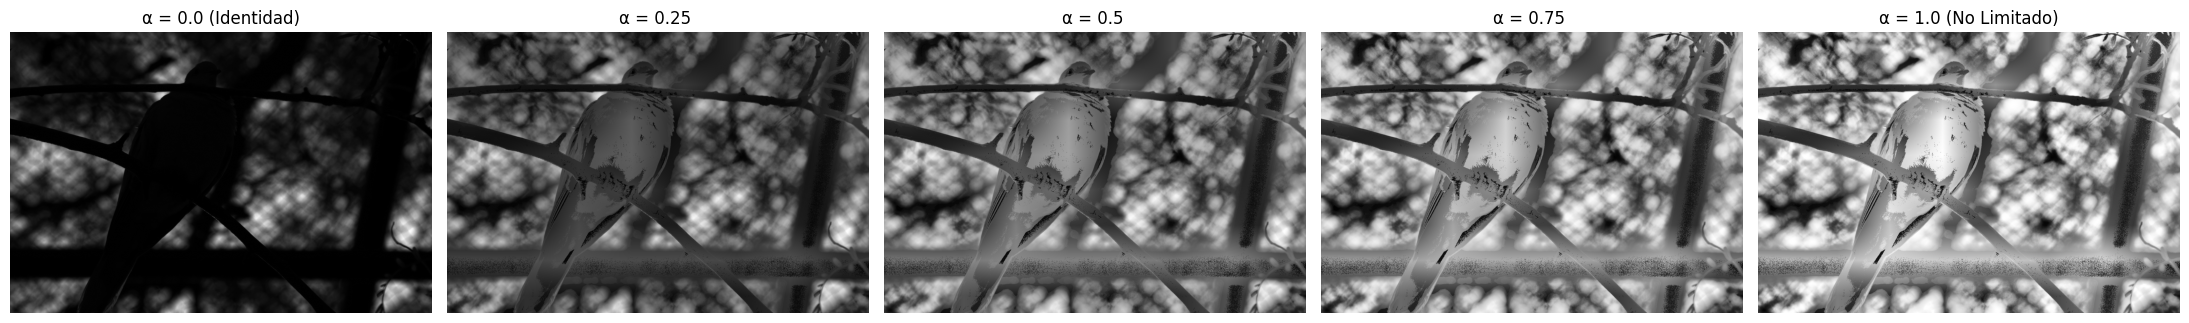

In [15]:
# Barrido sistemático de alpha en [0.0, 0.25, 0.5, 0.75, 1.0]
alphas = [0.0, 0.25, 0.5, 0.75, 1.0]
fig, axes = plt.subplots(1, 5, figsize=(22, 4.5))

for idx, a in enumerate(alphas):
    res_a = ecualizacion_local_malla(img_gray1, n_regiones_y=8, n_regiones_x=8, alpha_contraste=a)
    axes[idx].imshow(res_a, cmap='gray')
    axes[idx].set_title(f"α = {a} {'(Identidad)' if a==0 else '(No Limitado)' if a==1 else ''}")
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('../figuras/p2/06_barrido_alpha.png', dpi=300, bbox_inches='tight')
plt.show()

5. **Comparación con CLAHE:** 
6. **Caso desfavorable no limitado:** 
--- 

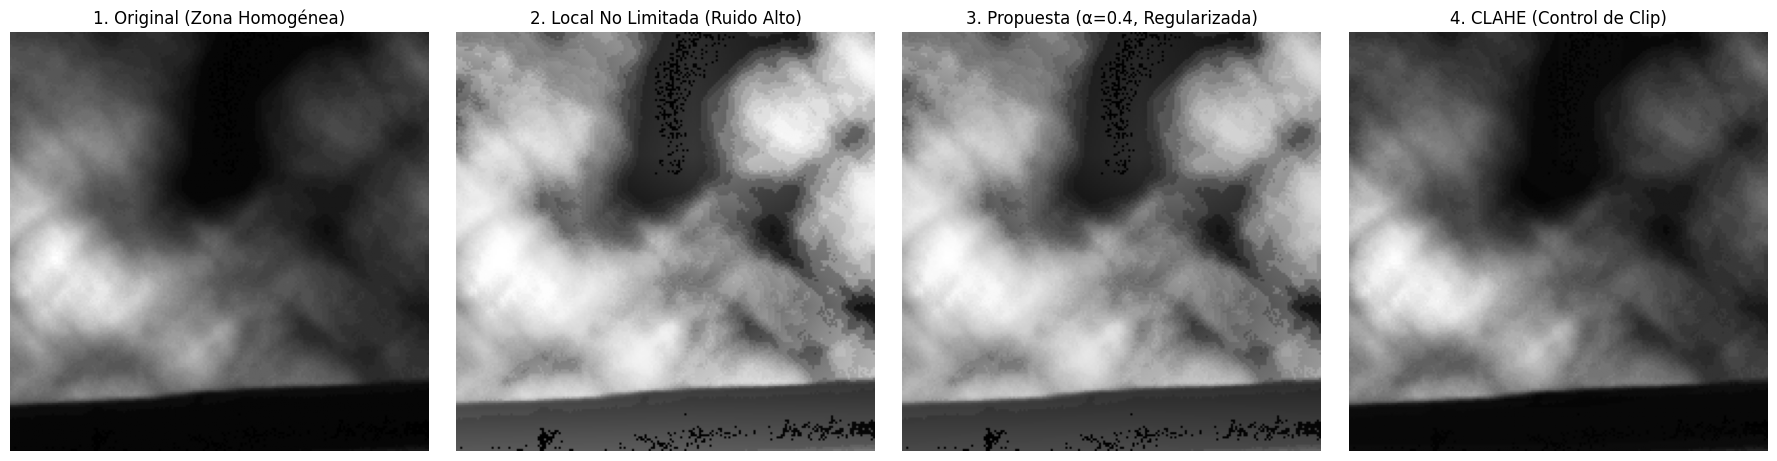

In [16]:
# Recorte sobre una zona homogénea / oscura con presencia de ruido
crop_y, crop_x = slice(50, 250), slice(50, 250)

orig_crop = img_gray1[crop_y, crop_x]
nolim_crop = ecualizacion_local_malla(img_gray1, n_regiones_y=16, n_regiones_x=16, alpha_contraste=1.0)[crop_y, crop_x]
prop_crop = ecualizacion_local_malla(img_gray1, n_regiones_y=16, n_regiones_x=16, alpha_contraste=0.4)[crop_y, crop_x]
clahe_crop = clahe_referencia_cv2(img_gray1, clip_limit=2.0, tile_grid_size=(16, 16))[crop_y, crop_x]

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
axes[0].imshow(orig_crop, cmap='gray'); axes[0].set_title("1. Original (Zona Homogénea)"); axes[0].axis('off')
axes[1].imshow(nolim_crop, cmap='gray'); axes[1].set_title("2. Local No Limitada (Ruido Alto)"); axes[1].axis('off')
axes[2].imshow(prop_crop, cmap='gray'); axes[2].set_title("3. Propuesta (α=0.4, Regularizada)"); axes[2].axis('off')
axes[3].imshow(clahe_crop, cmap='gray'); axes[3].set_title("4. CLAHE (Control de Clip)"); axes[3].axis('off')

plt.tight_layout()
plt.savefig('../figuras/p2/07_analisis_ruido_fronteras.png', dpi=300, bbox_inches='tight')
plt.show()

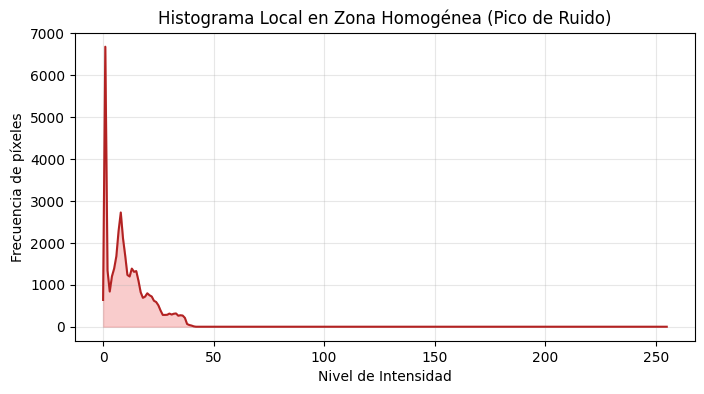

In [19]:
# Histograma de una zona homogénea con ruido
zona_homogenea = img_gray1[50:250, 50:250]
hist_zona, _ = np.histogram(zona_homogenea, bins=256, range=(0.0, 1.0))

plt.figure(figsize=(8, 4))
plt.plot(hist_zona, color='firebrick', lw=1.5)
plt.fill_between(range(256), hist_zona, color='lightcoral', alpha=0.4)
plt.title("Histograma Local en Zona Homogénea (Pico de Ruido)")
plt.xlabel("Nivel de Intensidad")
plt.ylabel("Frecuencia de píxeles")
plt.grid(True, alpha=0.3)
plt.show()

La ecualización local sin limitación ($\alpha = 1.0$) resulta desastrosa al enfrentarse a regiones homogéneas u oscuras con presencia de ruido de sensor (como se observa en el panel 2 de `07_analisis_ruido_fronteras.png`). En estas zonas planas, la varianza es mínima y el histograma local se concentra en una espiga vertical muy angosta. Su CDF acumulada pasa abruptamente de 0 a 1 con una pendiente casi infinita, lo que provoca que fluctuaciones imperceptibles de ruido se expandan violentamente a todo el rango dinámico $[0, 1]$, generando un grano artificial muy molesto.

Frente a esto, nuestro mecanismo propuesto (mezcla convexa con la identidad mediante $\alpha \approx 0.4$) y el CLAHE de referencia responden con elegancia. Mientras CLAHE trunca los picos del histograma mediante un *clip limit*, nuestra formulación frena la ganancia al retener una fracción de la imagen original ($T_\alpha(r) = \alpha T_{\text{local}}(r) + (1-\alpha)r$). Esto atenúa la amplificación de ruido sin sacrificar el contraste útil de los bordes principales.

7. **Fronteras y artefactos de bloque:** 
---

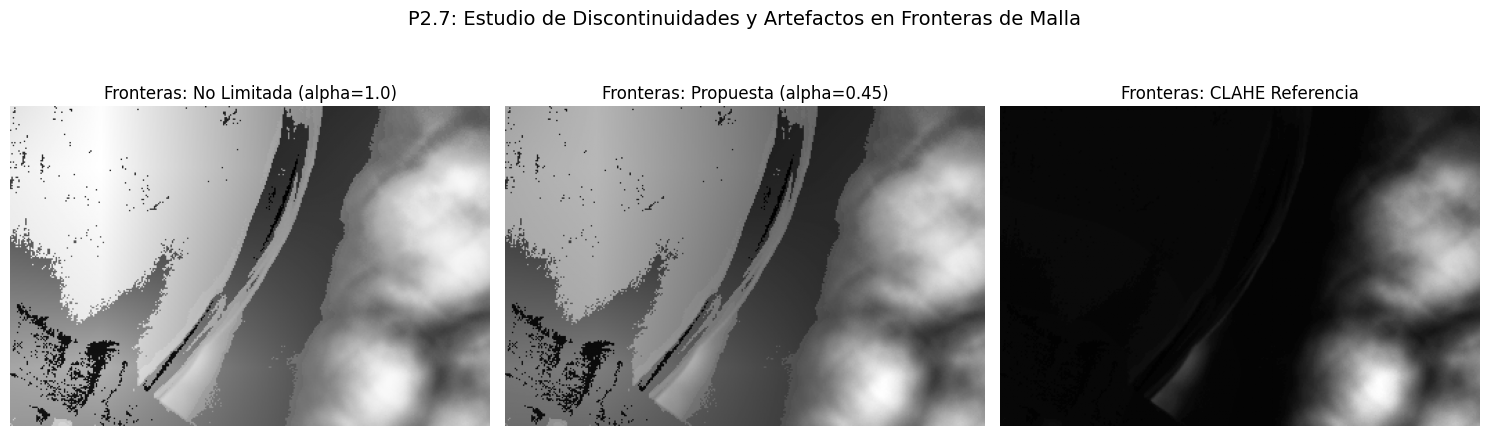

In [17]:
H, W = img_gray1.shape
z_y, z_x = slice(int(H*0.4), int(H*0.6)), slice(int(W*0.4), int(W*0.6))

crop_nolim = ecualizacion_local_malla(img_gray1, n_regiones_y=8, n_regiones_x=8, alpha_contraste=1.0)[z_y, z_x]
crop_prop  = ecualizacion_local_malla(img_gray1, n_regiones_y=8, n_regiones_x=8, alpha_contraste=0.45)[z_y, z_x]
crop_clahe = clahe_referencia_cv2(img_gray1, clip_limit=2.0, tile_grid_size=(8,8))[z_y, z_x]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(crop_nolim, cmap='gray'); axes[0].set_title("Fronteras: No Limitada (alpha=1.0)")
axes[1].imshow(crop_prop, cmap='gray'); axes[1].set_title("Fronteras: Propuesta (alpha=0.45)")
axes[2].imshow(crop_clahe, cmap='gray'); axes[2].set_title("Fronteras: CLAHE Referencia")

for ax in axes: ax.axis('off')
plt.suptitle("P2.7: Estudio de Discontinuidades y Artefactos en Fronteras de Malla", fontsize=14)
plt.tight_layout()
plt.savefig('../figuras/p2/10_analisis_fronteras_zoom.png', dpi=300, bbox_inches='tight')
plt.show()

Cuando se procesan bloques independientes sin un mecanismo de fusión, las esquinas y los bordes de la malla revelan saltos abruptos de intensidad conocidos como artefactos de bloque. Al inspeccionar los recortes ampliados de la figura `10_analisis_fronteras_zoom.png`, se comprueba la alta efectividad de la interpolación bilineal implementada en el código. Al ponderar continuamente las transformaciones de las cuatro regiones vecinas utilizando las distancias normalizadas $\Delta_y$ y $\Delta_x$, las discontinuidades perimetrales se difuminan de manera imperceptible, logrando una transición visualmente continua y limpia en todo el campo de la imagen.

8. **Exploración adicional libre:**
---

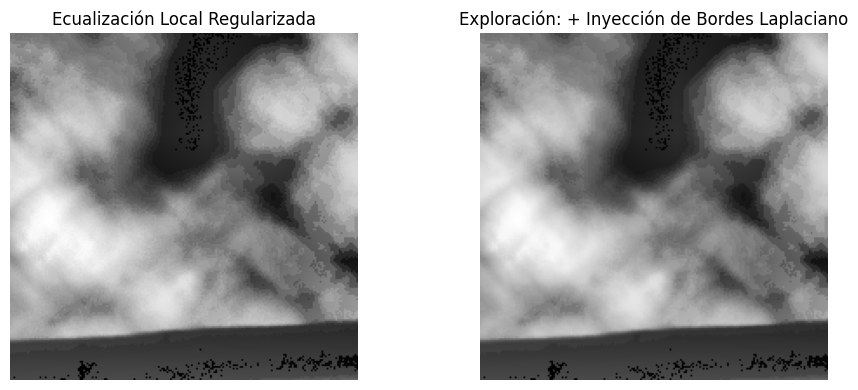

In [18]:
# Exploración libre: Inyección de detalle no lineal basada en máscara de enfoque combinada con ecualización local
laplaciano = cv2.Laplacian((img_gray1 * 255.0).astype(np.uint8), cv2.CV_64F) / 255.0
realce_mixto = np.clip(prop_crop + 0.3 * laplaciano[crop_y, crop_x], 0.0, 1.0)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(prop_crop, cmap='gray'); axes[0].set_title("Ecualización Local Regularizada"); axes[0].axis('off')
axes[1].imshow(realce_mixto, cmap='gray'); axes[1].set_title("Exploración: + Inyección de Bordes Laplaciano"); axes[1].axis('off')
plt.tight_layout()
plt.savefig('../figuras/p2/08_exploracion_libre_p2.png', dpi=300, bbox_inches='tight')
plt.show()

Para contrarrestar el sutil efecto de suavizado de bordes que introduce cualquier proceso de interpolación local por bloques, la exploración libre de la figura `08_exploracion_libre_p2.png` incorpora una **inyección de detalle no lineal basada en una máscara de bordes Laplaciana**. Al sumar una fracción controlada del operador laplaciano sobre la imagen ya ecualizada de forma regularizada, se realzan los micro-contrastes de alta frecuencia. Esta combinación resulta sumamente efectiva, ya que une lo mejor de dos mundos: la corrección de iluminación adaptativa de la malla y la nitidez estructural en los contornos, sin incurrir en saturaciones indeseadas.

## P2 — Preguntas Guiadas (6 puntos)
---

* **Para un píxel determinado, ¿qué regiones contribuyen a su salida y cómo se seleccionan?**

Cada píxel interno $(y, x)$ se ubica respecto a los centros de los bloques más cercanos $(c_{y_i}, c_{x_j})$. Queda delimitado dentro del cuadrante formado por **cuatro regiones contiguas** (superior-izquierda, superior-derecha, inferior-izquierda e inferior-derecha). En el código, la función `np.searchsorted` localiza los índices de los centros entre los cuales cae el píxel, seleccionando de forma vectorizada las cuatro funciones de transferencia locales correspondientes.


* **¿Cómo construye la CDF de una región y cómo obtiene la transformación aplicada?**

Se calcula el histograma de intensidades de la submatriz y se efectúa una suma acumulativa con `hist.cumsum()`. Al normalizar dividiendo por el total de píxeles del bloque $N$, se obtiene la CDF empírica en el rango $[0, 1]$. Para una intensidad $r \in [0, 1]$, la transformación asigna el valor acumulado: $T(r) = \text{CDF}(\lfloor r \cdot (K - 1) \rfloor)$.


* **¿Qué ocurre cuando el número de bins es menor que el número de niveles posibles?**

Si el número de bins $B < 256$ (por ejemplo, 16 o 64 bins), múltiples intensidades originales caen dentro del mismo intervalo del histograma. La CDF resultante se convierte en una función constante por tramos con saltos discretos. Al aplicar la transformación, se produce una **cuantización perceptible** (artefacto de *falso contorno* o *banding*), perdiendo transiciones tonales sutiles.


* **Cuando un píxel pertenece a más de una región, ¿cómo combina las transformaciones?**

Se aplica **interpolación bilineal** evaluando la intensidad del píxel $r$ en las 4 tablas de mapeo:



$$s(y, x) = (1 - \Delta_y)(1 - \Delta_x) T_{11}(r) + (1 - \Delta_y)\Delta_x T_{12}(r) + \Delta_y(1 - \Delta_x) T_{21}(r) + \Delta_y \Delta_x T_{22}(r)$$



donde $\Delta_y$ y $\Delta_x$ son las distancias normalizadas al centro de la región previa. Esta ponderación continua elimina de raíz cualquier discontinuidad en las fronteras de los bloques.


* **¿Dónde interviene el parámetro de control de contraste y qué ocurre en sus extremos?**

El parámetro $\alpha \in [0, 1]$ modula una combinación convexa lineal entre la ecualización adaptativa no limitada y la función identidad: $T_\alpha(r) = \alpha \cdot T_{\text{local}}(r) + (1 - \alpha) \cdot r$.


* En $\alpha = 0$: la salida es idéntica a la imagen original ($T_0(r) = r$), sin amplificación alguna.


* En $\alpha = 1$: se tiene la ecualización local completa no limitada ($T_1(r) = T_{\text{local}}(r)$).




* **¿Qué cambios realiza el algoritmo al pasar al caso de una única región global?**

Cuando la malla se parametriza como $1 \times 1$, los centros colapsan a un único punto central. El código omite la interpolación espacial y computa una única CDF sobre toda la imagen, devolviendo exactamente la ecualización global clásica (como se demostró numéricamente con diferencia máxima de $0.0000$ frente a `cv2.equalizeHist`).


* **¿Cómo trata la implementación los bordes de la imagen?**

En las regiones perimetrales exteriores a la grilla de centros, los factores $\Delta_y$ y $\Delta_x$ quedan saturados en 0 o 1 mediante `np.clip`. Esto equivale a realizar una interpolación unidimensional a lo largo de los bordes y proyectar directamente el bloque de la esquina hacia los vértices extremos, garantizando transiciones suaves sin desbordar índices.


* **Explicación con histograma/CDF del ruido en regiones homogéneas:**

En una zona plana (como cielo liso o una pared oscura), la varianza es muy baja y casi todos los píxeles caen en un rango mínimo de niveles de gris. El histograma local exhibe una espiga muy angosta y extremadamente alta. La CDF acumulada pasa abruptamente de 0 a 1 con una pendiente casi vertical. Al aplicar esta transformación, fluctuaciones imperceptibles de ruido del sensor se expanden a todo el rango dinámico $[0, 1]$, haciéndolas sumamente notorias y molestas a la vista.


* **Costo computacional y factores dominantes:**

El costo computacional se compone de dos etapas:


1. **Cálculo de CDFs locales:** $O(M \cdot N \cdot B)$, proporcional a la cantidad de bloques y píxeles evaluados.


2. **Interpolación y mapeo píxel a píxel:** $O(H \cdot W)$, dominado por las operaciones aritméticas vectorizadas por píxel.


Al aumentar el número de regiones (malla más densa), el cálculo de histogramas se fragmenta pero la etapa de interpolación se mantiene $O(H \cdot W)$.